In [21]:
from logger import setup_logger
from typing import Annotated, TypedDict, Any

from langchain_core.messages import AIMessage, ToolMessage, HumanMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field, ValidationError
from langgraph.graph import StateGraph, END, add_messages
from rag import hybrid_search
from tenacity import retry, stop_after_attempt, wait_exponential
from dotenv import load_dotenv
import os
import json
load_dotenv()


logger = setup_logger(__name__)

In [22]:
RELEVANCE_THRESHOLD = float(os.getenv("RELEVANCE_THRESHOLD", "0.65"))
GRADER_MODEL = os.getenv("GRADER_MODEL", "gpt-4.1-mini")
GRADER_TEMPERATURE = float(os.getenv("GRADER_TEMPERATURE", "0.0"))

In [23]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    question: str
    sources: list[dict]
    grade: bool
    retries: int


SEARCH_TOOL_SCHEMA = {
    "type": "function",
    "function": {
        "name": "search_documents",
        "description": """Search the indexed PDF documents for passages relevant 
        to the query. Call this whenever you need information from the documents""",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The search query"
                }
            },
            "required": ["query"]
        }
    }
}

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools([SEARCH_TOOL_SCHEMA])
MAX_RETRIES = 2


In [24]:
def agent_node(state: AgentState) -> dict:
    """LLM decides whether to call search_documents or produce final answer."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


def tool_node(state: AgentState) -> dict:
    """Execute tool calls from the last agent message, update latest sources only."""

    last_message: AIMessage = state["messages"][-1]
    tool_messages = []
    new_sources = []

    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "search_documents":
            query = tool_call["args"]["query"]
            logger.info(f"ReAct search: {query!r}")

            docs = hybrid_search(query, k=5)
            result_text = "\n\n".join(d.page_content for d in docs)

            for d in docs:
                new_sources.append({
                    "content": d.page_content,
                    "page": d.metadata.get("page"),
                    "source": d.metadata.get("source")
                })

            tool_messages.append(ToolMessage(
                content=result_text,
                tool_call_id=tool_call['id'],
                name="search_documents"
            ))

    return {
        "messages": tool_messages,
        "sources": new_sources,
    }


def should_continue(state: AgentState) -> str:
    """Route: if the agent emitted tool calls, go to tool. Otherwise end."""
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END


def rewrite_query_node(state: AgentState) -> dict:
    """Rewrite user question into a sharper retrieval query."""
    question = state.get("question", "")
    rewrite_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = (
        "Rewrite the question into one short search query for semantic retrieval. "
        "Return only the rewritten query string.\n\n"
        f"Question: {question}"
    )
    rewritten_query = rewrite_llm.invoke(prompt).content.strip()
    logger.info(f"[CorrectiveRAG] rewritten query: {rewritten_query!r}")

    return {
        "messages": [HumanMessage(content=f"Search documents for: {rewritten_query}")],
        "question": rewritten_query,
    }


def fallback_node(state: AgentState) -> dict:
    """Graceful stop when retrieval quality stays poor."""
    message = AIMessage(
        content=(
            "I could not find enough reliable evidence in the indexed documents "
            "to answer this confidently. Please try a more specific question "
            "or ingest additional documents."
        )
    )
    return {"messages": [message]}


def route_after_grader(state: AgentState) -> str:
    if state.get("grade", False):
        return "agent"
    if state.get("retries", 0) >= MAX_RETRIES:
        return "fallback"
    return "rewrite"


In [25]:
class GradeResult(BaseModel):
    relevant: bool = Field(description="Whether the chunk is relevant to answer the question")
    score: float = Field(ge=0.0, le=1.0, description="Relevance score in [0,1]")
    reason: str = Field(default="")


# single reusable grader client
grader_llm = ChatOpenAI(
    model=GRADER_MODEL,
    temperature=GRADER_TEMPERATURE,
)


def _grade_single_doc_llm(question: str, doc_content: str) -> GradeResult:
    """
    LLM grader: returns structured relevance for one document chunk.
    Falls back to non-relevant if parsing fails.
    """
    prompt = f"""
You are a strict relevance grader for a RAG pipeline.

Question:
{question}

Document chunk:
{doc_content[:4000]}

Task:
Judge if this chunk is useful for answering the question.

Return ONLY valid JSON with this exact schema:
{{
  "relevant": true/false,
  "score": <float 0 to 1>,
  "reason": "<one short sentence>"
}}

Rules:
- Be conservative.
- relevant=true only if chunk contains direct or strongly supporting evidence.
- score >= 0.65 usually means relevant.
""".strip()

    try:
        raw = grader_llm.invoke(prompt).content
        data = json.loads(raw)
        return GradeResult(**data)
    except (json.JSONDecodeError, ValidationError, Exception):
        # safe fallback: treat as not relevant
        return GradeResult(relevant=False, score=0.0, reason="grader_parse_failed")


def grade_documents_node(state: AgentState) -> dict[str, Any]:
    """
    Expects retrieved docs in state['sources'] from tool_node:
      [{"content": "...", "page": ..., "source": ...}, ...]
    Returns filtered sources + grade bool.
    """
    question = state.get("question", "")
    if not question:
        for msg in reversed(state.get("messages", [])):
            content = getattr(msg, "content", None)
            if isinstance(content, str) and content.strip():
                question = content
                break

    retrieved = state.get("sources", [])
    relevant_docs: list[dict[str, Any]] = []

    for d in retrieved:
        content = d.get("content", "")
        result = _grade_single_doc_llm(question, content)

        doc_with_grade = {
            **d,
            "relevance_score": result.score,
            "relevance_reason": result.reason,
        }

        if result.relevant and result.score >= RELEVANCE_THRESHOLD:
            relevant_docs.append(doc_with_grade)

    relevant_count = len(relevant_docs)
    total_count = len(retrieved)

    logger.info(
        f"[CorrectiveRAG] graded relevant={relevant_count} total={total_count}"
    )

    grade_ok = relevant_count > 0
    retries = state.get("retries", 0)
    if not grade_ok:
        retries += 1

    return {
        "sources": relevant_docs,
        "grade": grade_ok,
        "relevant_count": relevant_count,
        "total_count": total_count,
        "retries": retries,
    }


In [26]:
graph = StateGraph(AgentState)
graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node)
graph.add_node("grader", grade_documents_node)
graph.add_node("rewrite", rewrite_query_node)
graph.add_node("fallback", fallback_node)

graph.set_entry_point("agent")
graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph.add_edge("tools", "grader")
graph.add_conditional_edges(
    "grader",
    route_after_grader,
    {"agent": "agent", "rewrite": "rewrite", "fallback": "fallback"},
)
graph.add_edge("rewrite", "agent")
graph.add_edge("fallback", END)

react_agent = graph.compile()


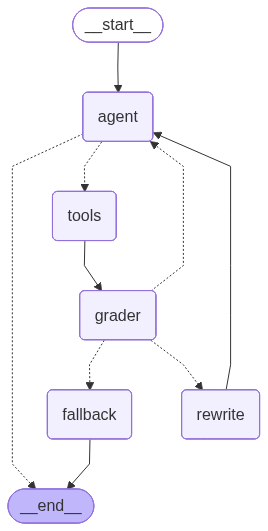

In [27]:
react_agent

In [9]:
@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=4,
                                                         max=10))
def answer_question(question: str) -> tuple[str, list[dict]]:
    system_prompt = (
        "You are a grounded assistant for PDF QA. "
        "Use search_documents when evidence is missing. "
        "If retrieved evidence is weak, try a better rewritten query. "
        "If evidence remains insufficient, say so clearly and do not hallucinate."
    )

    result = react_agent.invoke(
        {
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": question}
            ],
            "question": question,
            "sources": [],
            "grade": False,
            "retries": 0,
        }, config={"recursion_limit": 10}
    )

    answer = result["messages"][-1].content
    sources = result.get("sources", [])
    logger.info(f"ReAct answer generated, {len(sources)} source chunks used")

    return answer, sources
